In [1]:
!pip install -q kaggle

In [2]:
import os
from google.colab import userdata

os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

print("Kaggle credentials loaded successfully.")

Kaggle credentials loaded successfully.


In [3]:
!kaggle datasets list

ref                                                                 title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                                      Social Media Impact on Teen Mental Health                16190  2026-04-05 08:04:21.823000          12571        275                1  
syedaeman2212/shoes-sales-dataset                                   Shoes Sales Dataset                                      18813  2026-04-23 16:28:33.087000            525         23                1  
nafeesalmahadi/superstore-sales-analytics-dataset-2026              Superstore Sales Analytics Dataset - 2026              3347509  2026-04-23 14:43:55.677000            733         24

In [6]:
!kaggle datasets list -s "cats vs dogs"

ref                                                    title                                                size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------  ---------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
shaunthesheep/microsoft-catsvsdogs-dataset             Cats-vs-Dogs                                    825979578  2020-03-12 05:34:30.730000         103015        942  0.875            
biaiscience/dogs-vs-cats                               Dogs vs Cats                                    856265363  2017-12-05 14:03:33.210000          30527        362  0.4375           
pybear/cats-vs-dogs                                    Cats -- VS -- Dogs                              825979578  2020-10-18 13:55:30.950000           3175        104  0.625            
sujaykapadnis/cats-vs-dogs                             Cats Vs Dogs   

In [7]:
!kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset -p /content/data

Dataset URL: https://www.kaggle.com/datasets/shaunthesheep/microsoft-catsvsdogs-dataset
License(s): other
100% 788M/788M [00:09<00:00, 90.5MB/s]



In [8]:
import zipfile
import os

zip_path = "/content/data/microsoft-catsvsdogs-dataset.zip"
extract_path = "/content/data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [9]:
import os

base_dir = "/content/data/PetImages"

print(os.listdir(base_dir))
print("Cat images:", len(os.listdir(os.path.join(base_dir, "Cat"))))
print("Dog images:", len(os.listdir(os.path.join(base_dir, "Dog"))))

['Cat', 'Dog']
Cat images: 12501
Dog images: 12501


In [11]:
from PIL import Image
import os

classes = ["Cat", "Dog"]

removed = 0

for class_name in classes:
    folder_path = os.path.join(base_dir, class_name)

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except:
            os.remove(img_path)
            print(class_name)
            removed += 1

print("Corrupted images removed:", removed)

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Corrupted images removed: 0


In [12]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 150
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    base_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training"
)

val_data = datagen.flow_from_directory(
    base_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation"
)

Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.


In [13]:
print(train_data.class_indices)

{'Cat': 0, 'Dog': 1}


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(IMG_SIZE, IMG_SIZE, 3)),MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation="relu"),MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation="relu"),MaxPooling2D(2, 2),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.25),

    Dense(64, activation="relu"),
    Dropout(0.25),

    Dense(1, activation="sigmoid")
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,836,673 (18.45 MB)

 Trainable params: 4,836,673 (18.45 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [16]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

Epoch 1/20
260/625 ━━━━━━━━━━━━━━━━━━━━ 29s 82ms/step - accuracy: 0.5173 - loss: 0.7672

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 75s 107ms/step - accuracy: 0.6014 - loss: 0.6595 - val_accuracy: 0.7225 - val_loss: 0.5449
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 99ms/step - accuracy: 0.7444 - loss: 0.5177 - val_accuracy: 0.7947 - val_loss: 0.4437
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 91s 115ms/step - accuracy: 0.7997 - loss: 0.4366 - val_accuracy: 0.7973 - val_loss: 0.4303
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 100ms/step - accuracy: 0.8368 - loss: 0.3683 - val_accuracy: 0.8283 - val_loss: 0.3909
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 98ms/step - accuracy: 0.8734 - loss: 0.2988 - val_accuracy: 0.8267 - val_loss: 0.3826
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 100ms/step - accuracy: 0.9086 - loss: 0.2220 - val_accuracy: 0.8363 - val_loss: 0.4267
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 92ms/step - accuracy: 0.9388 - loss: 0.1564 - val_accuracy: 0.8319 - val_loss: 0.4543
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 100ms/step - accuracy: 0.9560 - loss: 0.1157 - val_ac

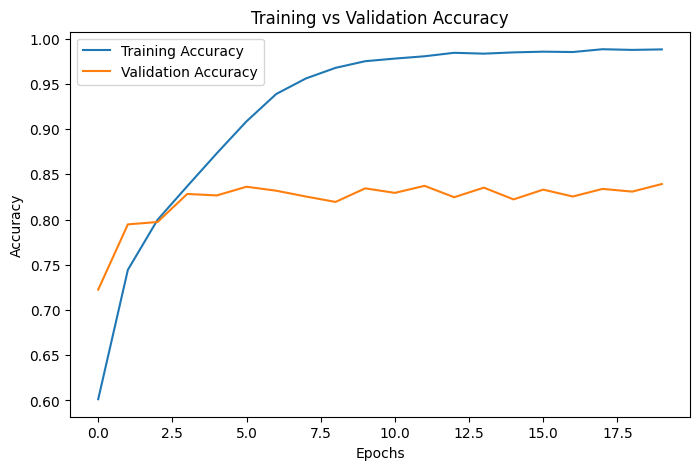

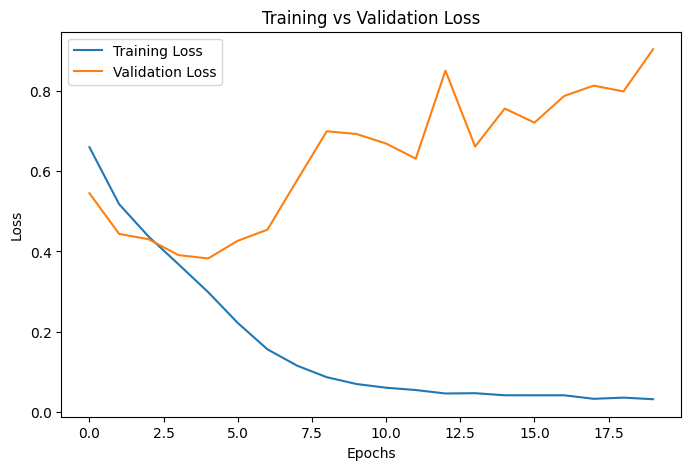

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [24]:
loss, accuracy = model.evaluate(val_data)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - accuracy: 0.8393 - loss: 0.9034
Validation Loss: 0.9034395217895508
Validation Accuracy: 0.8393357396125793


In [ ]:
model.save("/content/cat_dog_basic_cnn_model.h5")

print("Model saved successfully.")

Model saved successfully.


Saving images (2).jpg to images (2).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


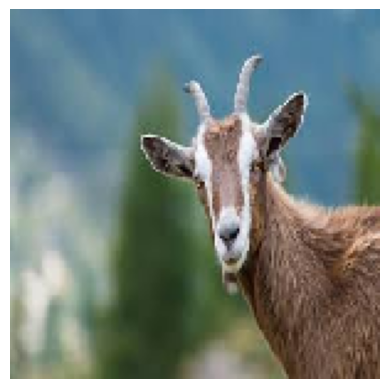

Prediction: Dog
Confidence: 0.896853


In [27]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

for file_name in uploaded.keys():
    img_path = file_name

    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)

    plt.imshow(img)
    plt.axis("off")
    plt.show()

    if prediction[0][0] > 0.5:
        print("Prediction: Dog")
        print("Confidence:", prediction[0][0])
    else:
        print("Prediction: Cat")
        print("Confidence:", 1 - prediction[0][0])